# Wine Review Sentiment Analysis  Project


In [1]:

# %pip install -q -U transformers accelerate datasets torch scikit-learn nltk flask scipy pandas numpy matplotlib joblib


##  Imports and configuration


In [2]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import re
import json
import time
import string
import warnings
from collections import Counter
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# A light, consistent look for every chart in the notebook so the
# figures don't each look like they came from a different project.
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

warnings.filterwarnings("ignore")

CONFIG = {
    "data_file": "winemag-data-130k-v2.csv",   # expected Kaggle file name
    "random_state": 42,                         # used everywhere so results are reproducible
    "sample_size": 4000,                        # how many reviews to work with
    "test_size": 0.2,                           # train/test split fraction
    "tfidf_max_features": 3000,                 # vocabulary cap for TF-IDF
    "transformer_model": "distilbert-base-uncased-finetuned-sst-2-english",
    "min_group_size": 10,                       # smallest group we'll report fairness metrics for
    "output_dir": "artifacts",                  # where models / logs get saved
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)
np.random.seed(CONFIG["random_state"])

print("Config loaded:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")


Config loaded:
  data_file: winemag-data-130k-v2.csv
  random_state: 42
  sample_size: 4000
  test_size: 0.2
  tfidf_max_features: 3000
  transformer_model: distilbert-base-uncased-finetuned-sst-2-english
  min_group_size: 10
  output_dir: artifacts


##  Load data 


In [4]:
def make_synthetic_wine_data(n_rows: int, random_state: int) -> pd.DataFrame:
    """Generate a small fake wine-review dataset with the same columns
    we need from the real Kaggle dataset. Only used when the real CSV
    is missing, so the notebook is always runnable end-to-end."""
    rng = np.random.default_rng(random_state)

    positive_phrases = [
        "a delightful wine with bright fruit and a smooth finish",
        "elegant, well balanced, and full of ripe cherry flavor",
        "an outstanding vintage with silky tannins and great depth",
        "crisp acidity and a long, satisfying aftertaste",
        "rich aromas of blackberry and a velvety texture on the palate",
    ]
    negative_phrases = [
        "a thin, watery wine with little character",
        "harsh tannins and an unpleasant bitter finish",
        "flat and lifeless, lacking any real fruit expression",
        "overly acidic with a sour, off-putting aroma",
        "disappointing and unbalanced, tastes almost like vinegar",
    ]
    countries = ["US", "France", "Italy", "Spain", "Chile"]

    rows = []
    for _ in range(n_rows):
        is_good = rng.random() > 0.45
        phrase = rng.choice(positive_phrases if is_good else negative_phrases)
        points = int(np.clip(rng.normal(90 if is_good else 82, 3), 80, 100))
        price = round(float(rng.gamma(2, 15) + (10 if is_good else 0)), 2)
        rows.append({
            "title": f"Synthetic Winery {rng.integers(1, 500)}",
            "description": phrase,
            "points": points,
            "price": price,
            "country": rng.choice(countries),
        })
    return pd.DataFrame(rows)


def load_wine_data(config: dict) -> pd.DataFrame:
    """Load the real Kaggle CSV if present, otherwise fall back to the
    synthetic generator above. Either way we return a DataFrame with the
    same columns, so nothing downstream needs to know which path was taken."""
    if os.path.exists(config["data_file"]):
        df = pd.read_csv(config["data_file"])
        print(f"Loaded REAL dataset: {df.shape}")
    else:
        print(f"'{config['data_file']}' not found — generating a synthetic "
              f"dataset instead so the notebook still runs end-to-end.")
        df = make_synthetic_wine_data(config["sample_size"], config["random_state"])
        print(f"Generated SYNTHETIC dataset: {df.shape}")
    return df


raw_df = load_wine_data(CONFIG)
raw_df.head()


Loaded REAL dataset: (129971, 14)


,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


## 4. Clean the data and define the label

We only keep the columns we actually use, drop rows with missing values in
those columns, and build the **quality proxy** label: a review is
"high quality" if its `points` is at or above the sample median. This mirrors
the earlier notebook's approach — sentiment is being tested as a *proxy* for
quality, not treated as equal to it.

In [5]:
# Keep only the columns the rest of the notebook needs.
keep_cols = [c for c in ["title", "description", "points", "price", "country"] if c in raw_df.columns]
df = raw_df[keep_cols].dropna().reset_index(drop=True)

# Sample down to a manageable size for a notebook-scale demo.
sample_n = min(CONFIG["sample_size"], len(df))
df = df.sample(sample_n, random_state=CONFIG["random_state"]).reset_index(drop=True)

# Binary label: 1 = "high quality" (points >= median), 0 = "low quality".
# This is a PROXY, not ground truth — a model that predicts this proxy well
# is predicting "does the review sound like a highly-rated wine", not
# "is this objectively a good wine".
median_points = df["points"].median()
df["quality_proxy"] = (df["points"] >= median_points).astype(int)

print(f"Working dataset shape: {df.shape}")
print(f"Median points used as the quality cutoff: {median_points}")
print(f"Class balance:\n{df['quality_proxy'].value_counts(normalize=True)}")
df.head()


Working dataset shape: (4000, 6)
Median points used as the quality cutoff: 88.0
Class balance:
quality_proxy
1    0.604
0    0.396
Name: proportion, dtype: float64


,title,description,points,price,country,quality_proxy
0,San Simeon 2009 Pinot Noir (Monterey),"A good everyday Pinot Noir, tart in acids and ...",86,18.0,US,0
1,Veuve du Vernay NV Brut Rosé Sparkling (Vin Mo...,"Round and fruity, this is cleanly made, with i...",85,10.0,France,0
2,Charles B. Mitchell 2012 Estate Grand Reserve ...,"Full-bodied and dry, this has a very deep, sat...",89,48.0,US,1
3,Florian Roblin 2015 Coulée des Moulins Sauvign...,This producer's style is for rich wines and th...,90,35.0,France,1
4,Vignerons de Buxy 2013 Buissonnier (Côte Chal...,"This attractive, lightly honeyed wine has appl...",86,18.0,France,0


## 5. Explore the data visually

Before training anything, it's worth *looking* at the data. This cell
draws four quick plots side by side:

1. **Class balance** — how many "high quality" vs "low quality" reviews
   we have (a bar chart makes an imbalanced dataset obvious at a
   glance, which raw `value_counts()` numbers can hide).
2. **Points distribution** — a histogram of the `points` score, with a
   dashed line marking the median we used as the quality cutoff.
3. **Price distribution** — prices are usually skewed (a few very
   expensive wines), so this shows that shape directly.
4. **Reviews per country** — which countries dominate the sample, so we
   know up front which fairness-check groups (section 15) will even
   have enough rows to be meaningful.

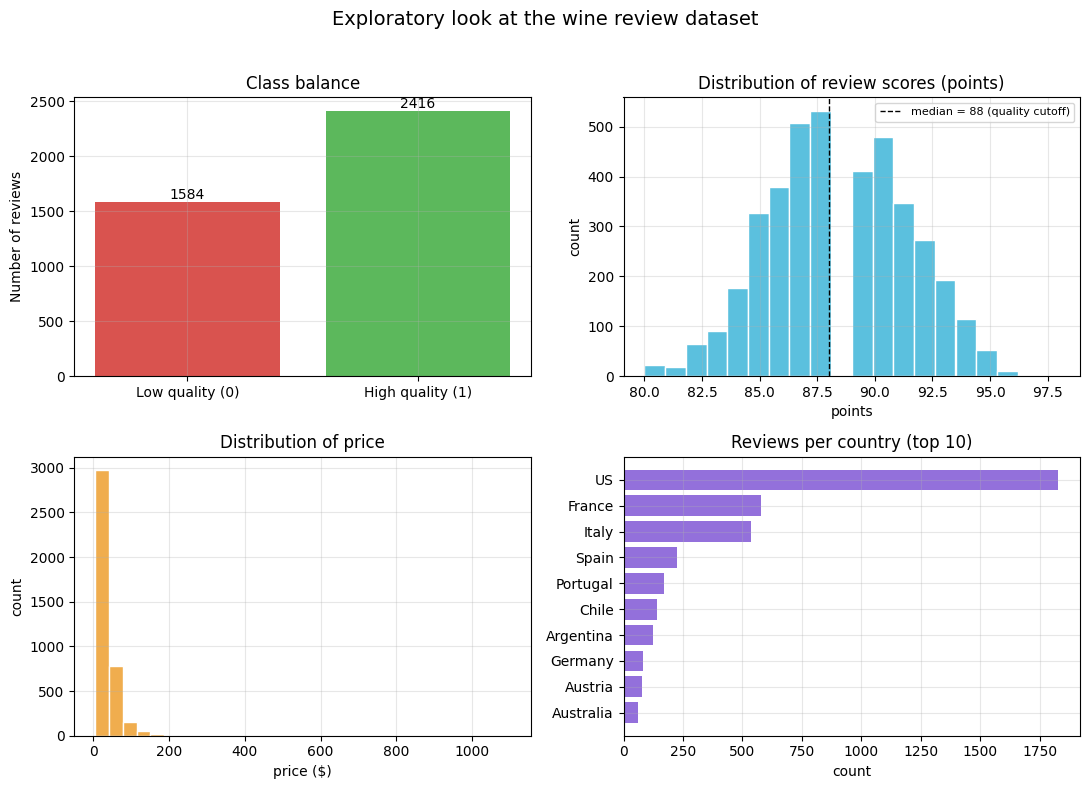

In [6]:
# Build one figure with 4 subplots (a 2x2 grid) so all the basic
# "what does this dataset look like" questions are answered in one view.
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.suptitle("Exploratory look at the wine review dataset", fontsize=14)

# --- 1. Class balance (how many high- vs low-quality reviews) ----------
class_counts = df["quality_proxy"].value_counts().sort_index()
axes[0, 0].bar(
    ["Low quality (0)", "High quality (1)"],
    class_counts.values,
    color=["#d9534f", "#5cb85c"],
)
axes[0, 0].set_title("Class balance")
axes[0, 0].set_ylabel("Number of reviews")
# Label each bar with its exact count, so you don't have to eyeball it.
for i, v in enumerate(class_counts.values):
    axes[0, 0].text(i, v, str(v), ha="center", va="bottom")

# --- 2. Distribution of the raw `points` score --------------------------
axes[0, 1].hist(df["points"], bins=20, color="#5bc0de", edgecolor="white")
axes[0, 1].axvline(
    median_points, color="black", linestyle="--", linewidth=1,
    label=f"median = {median_points:.0f} (quality cutoff)",
)
axes[0, 1].set_title("Distribution of review scores (points)")
axes[0, 1].set_xlabel("points")
axes[0, 1].set_ylabel("count")
axes[0, 1].legend(fontsize=8)

# --- 3. Distribution of price (usually right-skewed) --------------------
axes[1, 0].hist(df["price"], bins=30, color="#f0ad4e", edgecolor="white")
axes[1, 0].set_title("Distribution of price")
axes[1, 0].set_xlabel("price ($)")
axes[1, 0].set_ylabel("count")

# --- 4. How many reviews come from each country -------------------------
country_counts = df["country"].value_counts().head(10)  # top 10, else too crowded
axes[1, 1].barh(country_counts.index[::-1], country_counts.values[::-1], color="#9370DB")
axes[1, 1].set_title("Reviews per country (top 10)")
axes[1, 1].set_xlabel("count")

plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave room for the suptitle
plt.show()


## 6. Text cleaning helper

A small, dependency-light cleaning function: lowercase, strip punctuation,
split on whitespace, drop short/stopword tokens. We use scikit-learn's
built-in English stopword list instead of NLTK's so this cell needs **no
network download** — one less thing that can silently fail in a fresh
environment.

In [7]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def clean_and_tokenize(text: str) -> list:
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    tokens = text.split()
    return [t for t in tokens if t not in ENGLISH_STOP_WORDS and len(t) >= 3]

# Quick sanity check on one row.
example = df["description"].iloc[0]
print("Original: ", example)
print("Tokenized:", clean_and_tokenize(example))


Original:  A good everyday Pinot Noir, tart in acids and with some edgy tannins. But it has the variety's nice, silky texture, with rich cherry, rosehip tea and sandalwood flavors.
Tokenized: ['good', 'everyday', 'pinot', 'noir', 'tart', 'acids', 'edgy', 'tannins', 'variety', 'nice', 'silky', 'texture', 'rich', 'cherry', 'rosehip', 'tea', 'sandalwood', 'flavors']


## 7. Train/test split

One split, reused by every model below, so all comparisons are apples-to-apples.
`stratify=` keeps the positive/negative ratio the same in both splits.

In [8]:
# Use only the review text as the feature for the text models.
# Including columns like `title`, `points`, `price`, and `country` here would
# mix tabular features with text and break the model input shape.
X_train, X_test, y_train, y_test = train_test_split(
    df["description"],
    df["quality_proxy"],
    test_size=CONFIG["test_size"],
    random_state=CONFIG["random_state"],
    stratify=df["quality_proxy"],
)
print(f"Train rows: {len(X_train)}  |  Test rows: {len(X_test)}")


Train rows: 3200  |  Test rows: 800


## 8. Baseline model #1 — TF-IDF + Logistic Regression

This is a **real, trained** model: it learns weights from `X_train`/`y_train`,
not just a pretrained model applied out of the box. Wrapping vectorizer +
classifier in a single `Pipeline` means one object handles both steps, which
matters later when we save/load it for serving — no risk of saving the model
but forgetting the vectorizer (a very common bug).

In [9]:
from sklearn.pipeline import Pipeline

logreg_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=CONFIG["tfidf_max_features"], stop_words="english")),
    ("clf", LogisticRegression(max_iter=300, random_state=CONFIG["random_state"])),
])

logreg_pipeline.fit(X_train, y_train)
logreg_preds = logreg_pipeline.predict(X_test)

def evaluate(y_true, y_pred, model_name: str) -> dict:
    """One place to compute the metrics every model in this notebook is
    scored on, so the numbers are always comparable across models."""
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

logreg_metrics = evaluate(y_test, logreg_preds, "TFIDF + LogisticRegression")
logreg_metrics


{'model': 'TFIDF + LogisticRegression',
 'accuracy': 0.77,
 'precision': 0.7582037996545768,
 'recall': 0.9089026915113871,
 'f1': 0.8267419962335216}

## 9. Baseline model #2 — TF-IDF + Naive Bayes

A second trained baseline. Naive Bayes is fast, simple, and its learned
weights are directly interpretable (used again in the explainability
section below) — good to compare against the heavier transformer.

In [10]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=CONFIG["tfidf_max_features"], stop_words="english")),
    ("clf", MultinomialNB()),
])

nb_pipeline.fit(X_train, y_train)
nb_preds = nb_pipeline.predict(X_test)

nb_metrics = evaluate(y_test, nb_preds, "TFIDF + NaiveBayes")
nb_metrics


{'model': 'TFIDF + NaiveBayes',
 'accuracy': 0.72875,
 'precision': 0.7111111111111111,
 'recall': 0.927536231884058,
 'f1': 0.8050314465408805}

## 10. Pretrained transformer scorer (with a safe fallback)

This class wraps the pretrained DistilBERT sentiment pipeline. If
`transformers`/`torch` aren't installed (as in this sandbox), it prints a
warning once and falls back to a tiny hand-written lexicon scorer instead of
raising an exception — so the rest of the notebook (evaluation, comparison,
error analysis) still runs. When you install the real packages, this class
automatically switches to the real model with zero other code changes.

In [11]:
class SentimentScorer:
    """Thin wrapper around a sentiment model. Tries to load a real
    pretrained transformer; falls back to a simple keyword-count scorer
    if the heavy dependencies aren't available. Same interface either way,
    so callers never need to know which backend is active."""

    POSITIVE_WORDS = {"delightful", "elegant", "outstanding", "silky", "smooth",
                       "rich", "balanced", "great", "crisp", "satisfying", "velvety"}
    NEGATIVE_WORDS = {"thin", "watery", "harsh", "unpleasant", "flat", "lifeless",
                       "acidic", "sour", "disappointing", "unbalanced", "bitter"}

    def __init__(self, model_name: str):
        self.model_name = model_name
        self.backend = "fallback_lexicon"
        self.pipeline = None
        try:
            from transformers import pipeline  # heavy import, only needed here
            self.pipeline = pipeline(task="sentiment-analysis", model=model_name)
            self.backend = "transformer"
        except Exception as e:
            print(f"[SentimentScorer] Could not load transformer model "
                  f"({type(e).__name__}: {e}). Falling back to a lexicon-based "
                  f"scorer so the notebook keeps working. Install `transformers` "
                  f"and `torch` to use the real model.")

    def predict_one(self, text: str) -> dict:
        if self.backend == "transformer":
            result = self.pipeline(text)[0]
            return {"label": result["label"], "score": round(result["score"], 3)}
        # --- fallback: simple positive/negative word count ---
        tokens = set(clean_and_tokenize(text))
        pos_hits = len(tokens & self.POSITIVE_WORDS)
        neg_hits = len(tokens & self.NEGATIVE_WORDS)
        label = "POSITIVE" if pos_hits >= neg_hits else "NEGATIVE"
        total = max(pos_hits + neg_hits, 1)
        confidence = round(max(pos_hits, neg_hits) / total, 3) if (pos_hits or neg_hits) else 0.5
        return {"label": label, "score": confidence}

    def predict_batch(self, texts) -> list:
        return [self.predict_one(t) for t in texts]


scorer = SentimentScorer(CONFIG["transformer_model"])
print(f"Active backend: {scorer.backend}")
print(scorer.predict_one("This wine was absolutely delicious!"))


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 637.94it/s]
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english/resolve/main/processor_config.json
Retrying in 1s [Retry 1/5].
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english/resolve/main/processor_config.json
Retrying in 2s [Retry 2/5].
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english/resolve/main/processor_config.json
Retrying in 4s [Retry 3/5].


Active backend: transformer
{'label': 'POSITIVE', 'score': 1.0}


## 11. Score the test set with the transformer scorer

Run the scorer over the same `X_test` the two baselines were evaluated on,
so all three models are compared on identical data.

In [12]:
transformer_results = scorer.predict_batch(X_test.tolist())
transformer_preds = pd.Series(
    [1 if r["label"] == "POSITIVE" else 0 for r in transformer_results],
    index=X_test.index,
)
transformer_confidences = pd.Series([r["score"] for r in transformer_results], index=X_test.index)

transformer_metrics = evaluate(y_test, transformer_preds, f"Transformer ({scorer.backend})")
transformer_metrics


{'model': 'Transformer (transformer)',
 'accuracy': 0.645,
 'precision': 0.6321381142098274,
 'recall': 0.9855072463768116,
 'f1': 0.7702265372168284}

## 12. Compare all three models side by side

Putting every model's metrics into one DataFrame is what actually lets you
answer "which model should we ship" — a single printed number from one
model in isolation never does.

                            accuracy  precision  recall     f1
model                                                         
TFIDF + LogisticRegression     0.770      0.758   0.909  0.827
TFIDF + NaiveBayes             0.729      0.711   0.928  0.805
Transformer (transformer)      0.645      0.632   0.986  0.770


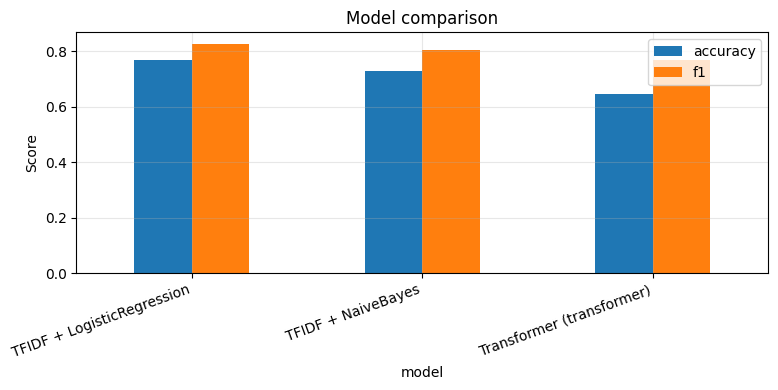

In [13]:
comparison_df = pd.DataFrame([logreg_metrics, nb_metrics, transformer_metrics]).set_index("model")
comparison_df = comparison_df.round(3)
print(comparison_df)

comparison_df[["accuracy", "f1"]].plot(kind="bar", figsize=(8, 4), title="Model comparison")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 13. Confusion matrices for every model

The bar chart above tells you *how well* each model scores overall,
but not *what kind* of mistakes it makes. A confusion matrix answers
that: for each model, how many predictions were correct vs which way
they were wrong (false positives vs false negatives). Comparing three
side by side makes it easy to spot, e.g., a model that is simply
biased toward predicting one class.

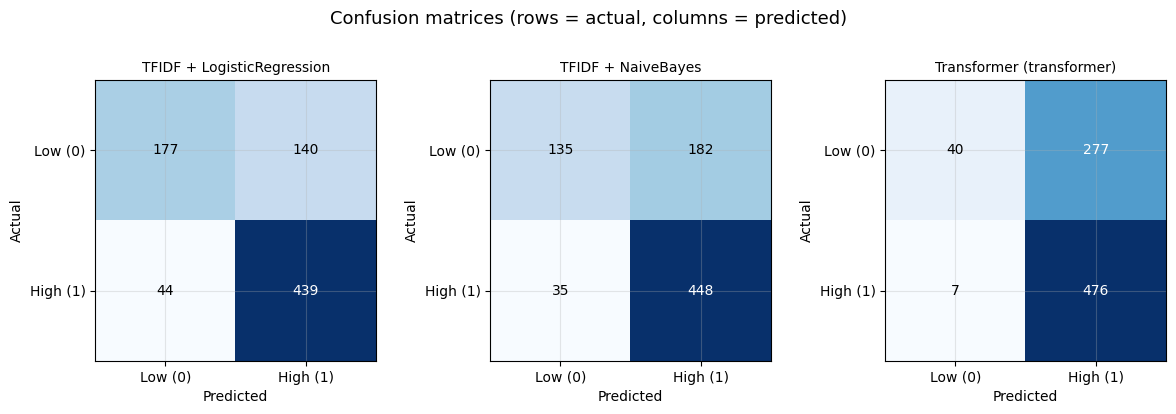

In [14]:
from sklearn.metrics import confusion_matrix

# Same three prediction sets used in the comparison table above.
model_predictions = {
    "TFIDF + LogisticRegression": logreg_preds,
    "TFIDF + NaiveBayes": nb_preds,
    f"Transformer ({scorer.backend})": transformer_preds,
}

fig, axes = plt.subplots(1, len(model_predictions), figsize=(4 * len(model_predictions), 4))
fig.suptitle("Confusion matrices (rows = actual, columns = predicted)", fontsize=13)

for ax, (name, preds) in zip(axes, model_predictions.items()):
    cm = confusion_matrix(y_test, preds, labels=[0, 1])

    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(name, fontsize=10)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Low (0)", "High (1)"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Low (0)", "High (1)"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    # Write the raw count in the middle of each cell so the numbers are
    # readable without needing a separate legend/colorbar per subplot.
    for row in range(2):
        for col in range(2):
            value = cm[row, col]
            # Flip text color to white on the darkest (highest-count) cells
            # so the number stays legible against the Blues colormap.
            text_color = "white" if value > cm.max() / 2 else "black"
            ax.text(col, row, str(value), ha="center", va="center", color=text_color)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


## 14. Error analysis

Look at where the **best-performing model** (whichever scored highest F1
above) disagrees with the quality proxy. This is often more informative than
the aggregate metric — it tells you *what kind of* mistakes the model makes.

In [15]:
# Pick whichever model had the best F1 for the error analysis below.
best_model_name = comparison_df["f1"].idxmax()
preds_by_model = {
    "TFIDF + LogisticRegression": logreg_preds,
    "TFIDF + NaiveBayes": nb_preds,
    f"Transformer ({scorer.backend})": transformer_preds,
}
best_preds = pd.Series(preds_by_model[best_model_name], index=X_test.index)

results_df = pd.DataFrame({
    "description": X_test,
    "quality_proxy": y_test,
    "predicted": best_preds,
})
results_df["is_correct"] = results_df["quality_proxy"] == results_df["predicted"]
errors_df = results_df[~results_df["is_correct"]]

print(f"Best model by F1: {best_model_name}")
print(f"Errors: {len(errors_df)} / {len(results_df)} ({len(errors_df)/len(results_df)*100:.1f}%)")
print("\nA few misclassified examples:")
print(errors_df[["description", "quality_proxy", "predicted"]].head(5).to_string(index=False))


Best model by F1: TFIDF + LogisticRegression
Errors: 184 / 800 (23.0%)

A few misclassified examples:
                                                                                                                                                                                                                                   description  quality_proxy  predicted
                                                          A fresh nose suggests both green and yellow pears. The palate shines with the freshness of both fruits—crisp, sunny, light and very fruity. The finish is clean and very refreshing.              1          0
                  Dark cherry to garnet in color, it offers notes of blackberry, pomegranate and black cherry in its bouquet. A strong acidic backbone and persistent cranberry flavor at the finish make this a wine that calls out for food.              0          1
A dry, tannic Zinfandel from Amador, fairly large production at 14,000 cases a year, with enough bluebe

## 15. Aspect-based sentiment

Instead of scoring a whole review at once, split it into sentences and score
only the sentence(s) that mention a specific wine attribute (aroma, tannins,
acidity, etc.). This answers a more useful question than overall sentiment:
*which parts of the wine do reviewers like or dislike?*

In [16]:
WINE_ASPECTS = {
    "Aroma/Nose": ["aroma", "nose", "bouquet", "smell", "scent", "fragrance", "aromatic"],
    "Taste/Palate": ["taste", "palate", "flavor", "flavour", "flavors", "mouth"],
    "Finish": ["finish", "aftertaste", "lingering", "lingers"],
    "Tannins": ["tannin", "tannic", "tannins"],
    "Acidity": ["acid", "acidity", "acidic", "crisp"],
    "Fruit": ["fruit", "fruity", "berry", "cherry", "plum", "apple", "peach", "citrus"],
}

def split_sentences(text: str) -> list:
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if s.strip()]

aspect_rows = []
for review in df["description"]:
    sentences = split_sentences(review)
    for aspect, keywords in WINE_ASPECTS.items():
        # Only score the sentence(s) that actually mention this aspect,
        # not the whole review — that's what makes it "aspect-based"
        # rather than just overall sentiment repeated per aspect.
        matching = [s for s in sentences if any(k in s.lower() for k in keywords)]
        for sentence in matching:
            result = scorer.predict_one(sentence)
            aspect_rows.append({"aspect": aspect, "sentence": sentence, "label": result["label"]})

aspect_df = pd.DataFrame(aspect_rows)
if len(aspect_df):
    aspect_summary = (
        aspect_df.groupby("aspect")["label"]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .round(2)
    )
    print(aspect_summary)
else:
    print("No aspect-mentioning sentences found in this sample.")


label         NEGATIVE  POSITIVE
aspect                          
Acidity           0.10      0.90
Aroma/Nose        0.13      0.87
Finish            0.14      0.86
Fruit             0.09      0.91
Tannins           0.13      0.87
Taste/Palate      0.11      0.89


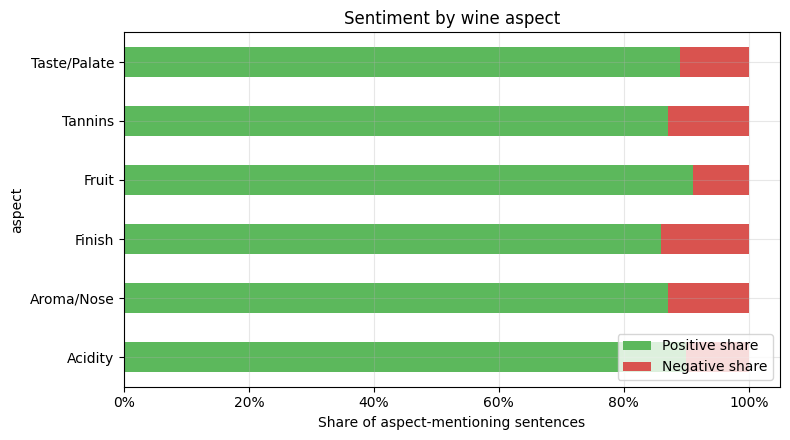

In [17]:
# Turn the aspect_summary table above into a stacked bar chart: one bar
# per wine aspect (aroma, taste, finish, ...), split into the POSITIVE vs
# NEGATIVE share of sentences that mention it. This is much faster to read
# than scanning a table of numbers, especially as more aspects get added.
if len(aspect_df):
    plot_df = aspect_summary.reindex(columns=["POSITIVE", "NEGATIVE"], fill_value=0)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_df["POSITIVE"].plot(
        kind="barh", ax=ax, color="#5cb85c", label="Positive share"
    )
    plot_df["NEGATIVE"].plot(
        kind="barh", ax=ax, left=plot_df["POSITIVE"], color="#d9534f", label="Negative share"
    )
    ax.set_xlabel("Share of aspect-mentioning sentences")
    ax.set_title("Sentiment by wine aspect")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
else:
    print("Nothing to plot — no aspect-mentioning sentences were found in this sample.")


## 16. Explainability — which words drive the Naive Bayes model

Naive Bayes gives us a clean, interpretable number per word: the log-odds
difference between the "high quality" and "low quality" classes. This is a
useful sanity check independent of the transformer — do the top words make
intuitive sense?

In [18]:
nb_vectorizer = nb_pipeline.named_steps["tfidf"]
nb_classifier = nb_pipeline.named_steps["clf"]

feature_names = nb_vectorizer.get_feature_names_out()
log_odds = nb_classifier.feature_log_prob_[1] - nb_classifier.feature_log_prob_[0]

top_n = 12
top_high_idx = np.argsort(log_odds)[-top_n:][::-1]
top_low_idx = np.argsort(log_odds)[:top_n]

print("Words most associated with HIGH quality proxy:")
for i in top_high_idx:
    print(f"  {feature_names[i]:15} {log_odds[i]:+.3f}")

print("\nWords most associated with LOW quality proxy:")
for i in top_low_idx:
    print(f"  {feature_names[i]:15} {log_odds[i]:+.3f}")


Words most associated with HIGH quality proxy:
  2020            +1.957
  powerful        +1.858
  2019            +1.589
  delicious       +1.562
  velvety         +1.559
  2025            +1.516
  2018            +1.473
  refined         +1.415
  lush            +1.413
  beautiful       +1.369
  layered         +1.320
  gorgeous        +1.309

Words most associated with LOW quality proxy:
  simple          -2.384
  generic         -2.364
  everyday        -2.208
  basic           -1.988
  dull            -1.898
  lacks           -1.773
  strange         -1.753
  scratchy        -1.735
  bell            -1.655
  harsh           -1.598
  minty           -1.583
  chilled         -1.565


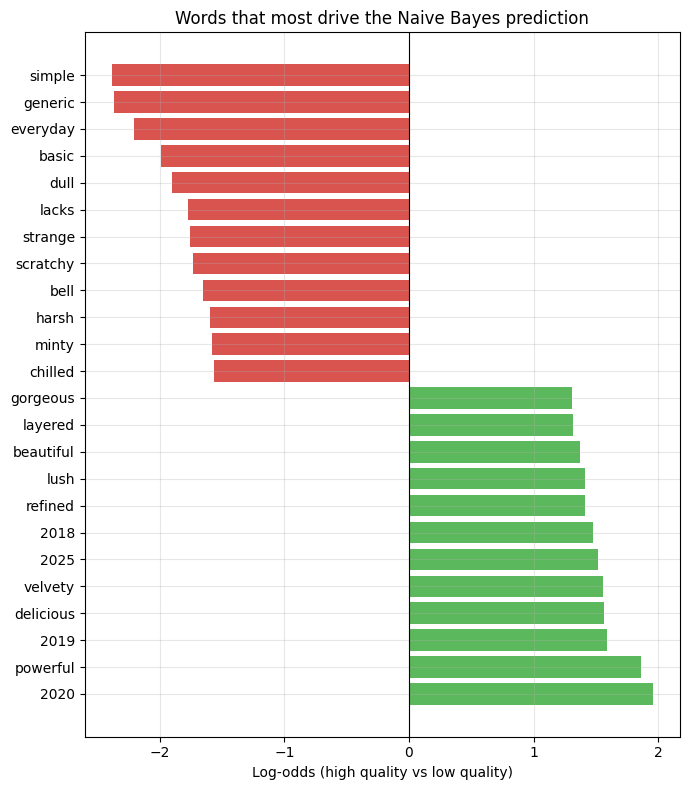

In [19]:
# Same top_high_idx / top_low_idx computed above — just plotted instead of
# printed, so the relative strength of each word's association is visible
# at a glance (a bigger bar = a stronger signal toward that class).
top_words = list(feature_names[top_high_idx]) + list(feature_names[top_low_idx])[::-1]
top_scores = list(log_odds[top_high_idx]) + list(log_odds[top_low_idx])[::-1]

colors = ["#5cb85c" if s > 0 else "#d9534f" for s in top_scores]

fig, ax = plt.subplots(figsize=(7, 8))
ax.barh(top_words, top_scores, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Log-odds (high quality vs low quality)")
ax.set_title("Words that most drive the Naive Bayes prediction")
plt.tight_layout()
plt.show()


## 17. Fairness / bias check across groups

Check whether the best model's accuracy holds up across subgroups (here,
`country`) instead of only reporting one overall number. Groups smaller than
`CONFIG["min_group_size"]` are skipped and flagged — a metric computed on 3
rows is noise, not a finding, and reporting it anyway is misleading.

In [20]:
if "country" in df.columns:
    test_with_country = df.loc[X_test.index, ["country"]].copy()
    test_with_country["quality_proxy"] = y_test.values
    test_with_country["predicted"] = best_preds.values

    fairness_rows = []
    for country, group in test_with_country.groupby("country"):
        if len(group) < CONFIG["min_group_size"]:
            print(f"Skipping {country}: only {len(group)} rows (< {CONFIG['min_group_size']})")
            continue
        fairness_rows.append({
            "country": country,
            "n": len(group),
            "accuracy": accuracy_score(group["quality_proxy"], group["predicted"]),
            "f1": f1_score(group["quality_proxy"], group["predicted"], zero_division=0),
        })

    fairness_df = pd.DataFrame(fairness_rows).round(3)
    print("\nAccuracy/F1 by country (only groups with enough rows):")
    print(fairness_df)
else:
    print("No 'country' column available for a fairness breakdown.")


Skipping Bulgaria: only 1 rows (< 10)
Skipping Canada: only 2 rows (< 10)
Skipping Greece: only 6 rows (< 10)
Skipping Hungary: only 2 rows (< 10)
Skipping India: only 1 rows (< 10)
Skipping Israel: only 3 rows (< 10)
Skipping Peru: only 1 rows (< 10)
Skipping Romania: only 2 rows (< 10)
Skipping Slovenia: only 1 rows (< 10)
Skipping South Africa: only 4 rows (< 10)
Skipping Turkey: only 2 rows (< 10)

Accuracy/F1 by country (only groups with enough rows):
        country    n  accuracy     f1
0     Argentina   23     0.739  0.571
1     Australia   20     0.750  0.828
2       Austria   13     0.923  0.960
3         Chile   27     0.778  0.667
4        France  129     0.791  0.851
5       Germany   15     0.800  0.889
6         Italy   93     0.763  0.841
7   New Zealand   12     0.750  0.769
8      Portugal   39     0.744  0.828
9         Spain   44     0.727  0.625
10           US  360     0.778  0.837


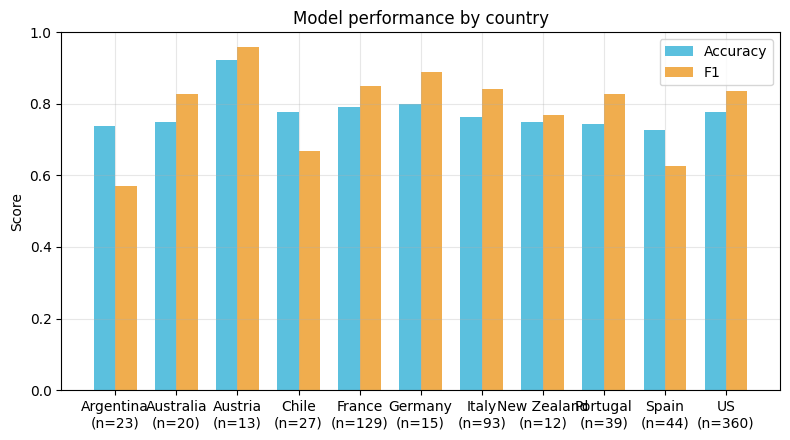

In [21]:
# Plot accuracy and F1 per country side by side so it's immediately clear
# whether the model's performance is roughly even across groups, or whether
# it does noticeably better/worse for some countries (a fairness red flag).
if "country" in df.columns and len(fairness_df):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    x = range(len(fairness_df))
    width = 0.35

    ax.bar([i - width / 2 for i in x], fairness_df["accuracy"], width, label="Accuracy", color="#5bc0de")
    ax.bar([i + width / 2 for i in x], fairness_df["f1"], width, label="F1", color="#f0ad4e")

    ax.set_xticks(list(x))
    # Include each group's row count (n) in the tick label, since a metric
    # on very few rows is much noisier than the same metric on many rows.
    ax.set_xticklabels([f"{c}\n(n={n})" for c, n in zip(fairness_df["country"], fairness_df["n"])])
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.set_title("Model performance by country")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Skipping fairness chart — no per-country results to plot.")


## 18. Fine-tuning scaffold (domain adaptation) — off by default

This is the actual engineering step the original notebook only sketched:
code to fine-tune DistilBERT on this dataset's own labels instead of only
running it out-of-the-box. It's guarded by `RUN_TRAINING = False` because it
needs a GPU and `transformers`/`datasets`/`torch` installed — flip the flag
and run it in an environment that has those.

In [22]:
RUN_TRAINING = False  # set True only on a machine with a GPU + the heavy deps installed

if RUN_TRAINING:
    from transformers import (
        DistilBertTokenizerFast, DistilBertForSequenceClassification,
        Trainer, TrainingArguments, DataCollatorWithPadding,
    )
    from datasets import Dataset

    tokenizer = DistilBertTokenizerFast.from_pretrained(CONFIG["transformer_model"])
    model = DistilBertForSequenceClassification.from_pretrained(CONFIG["transformer_model"], num_labels=2)

    train_ds = Dataset.from_dict({"text": X_train.tolist(), "label": y_train.tolist()})
    val_ds = Dataset.from_dict({"text": X_test.tolist(), "label": y_test.tolist()})

    def tokenize_fn(batch):
        return tokenizer(batch["text"], truncation=True, max_length=128)

    train_ds = train_ds.map(tokenize_fn, batched=True)
    val_ds = val_ds.map(tokenize_fn, batched=True)

    training_args = TrainingArguments(
        output_dir=os.path.join(CONFIG["output_dir"], "finetuned_model"),
        num_train_epochs=2,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=50,
        load_best_model_at_end=True,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    )
    trainer.train()
    trainer.save_model(os.path.join(CONFIG["output_dir"], "finetuned_model"))
    print("Fine-tuned model saved.")
else:
    print("RUN_TRAINING is False — skipping fine-tuning. "
          "Set it to True on a GPU machine with transformers/datasets/torch installed.")


RUN_TRAINING is False — skipping fine-tuning. Set it to True on a GPU machine with transformers/datasets/torch installed.


## 19. Save the best model + a model card

We persist the winning scikit-learn pipeline (vectorizer + classifier
together, so nothing gets out of sync) with `joblib`, plus a small
`model_card.json` recording *what* was saved, *when*, and *with what
metrics* — the minimum metadata you need to trust a model file six months
later.

In [23]:
import joblib

best_pipeline = {"TFIDF + LogisticRegression": logreg_pipeline,
                  "TFIDF + NaiveBayes": nb_pipeline}.get(best_model_name)

if best_pipeline is not None:
    model_path = os.path.join(CONFIG["output_dir"], "best_model.joblib")
    joblib.dump(best_pipeline, model_path)

    model_card = {
        "model_name": best_model_name,
        "saved_at_utc": datetime.now(timezone.utc).isoformat(),
        "metrics": comparison_df.loc[best_model_name].to_dict(),
        "config": CONFIG,
    }
    card_path = os.path.join(CONFIG["output_dir"], "model_card.json")
    with open(card_path, "w") as f:
        json.dump(model_card, f, indent=2)

    print(f"Saved model to:      {model_path}")
    print(f"Saved model card to: {card_path}")
else:
    print(f"Best model was the transformer ({best_model_name}) — nothing to "
          f"joblib-save here; it would be saved via trainer.save_model() "
          f"in the fine-tuning cell instead.")


Saved model to:      artifacts\best_model.joblib
Saved model card to: artifacts\model_card.json


## 20. Lightweight experiment log

A one-line-per-run CSV that every future run appends to — a "poor man's
MLflow". It's not a replacement for a real experiment tracker on a bigger
project, but it costs nothing to set up and already answers "did this run's
F1 go up or down compared to last time?".

In [24]:
def log_experiment(comparison_df: pd.DataFrame, config: dict) -> None:
    """Append one row per model per run to a persistent CSV log."""
    log_path = os.path.join(config["output_dir"], "experiments.csv")
    run_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")

    rows = comparison_df.reset_index().rename(columns={"index": "model"})
    rows.insert(0, "run_id", run_id)
    rows["sample_size"] = config["sample_size"]

    header_needed = not os.path.exists(log_path)
    rows.to_csv(log_path, mode="a", header=header_needed, index=False)
    print(f"Logged {len(rows)} rows to {log_path} under run_id={run_id}")

log_experiment(comparison_df, CONFIG)
pd.read_csv(os.path.join(CONFIG["output_dir"], "experiments.csv")).tail()


Logged 3 rows to artifacts\experiments.csv under run_id=20260926T194450Z


,run_id,model,accuracy,precision,recall,f1,sample_size
1,20260925T220034Z,TFIDF + NaiveBayes,0.729,0.711,0.928,0.805,4000
2,20260925T220034Z,Transformer (transformer),0.645,0.632,0.986,0.770,4000
3,20260926T194450Z,TFIDF + LogisticRegression,0.770,0.758,0.909,0.827,4000
4,20260926T194450Z,TFIDF + NaiveBayes,0.729,0.711,0.928,0.805,4000
5,20260926T194450Z,Transformer (transformer),0.645,0.632,0.986,0.770,4000


## 21. Minimal serving script

Writes a small standalone `app.py` (Flask) that loads `best_model.joblib`
and exposes one endpoint: `POST /predict {"description": "..."}` ->
`{"label": ..., "confidence": ...}`. It's written to a file rather than run
inline, since a web server blocks the notebook — run it separately with
`python artifacts/app.py`.

In [25]:
app_code = '''"""
Minimal Flask server for the wine-sentiment model.
Run with:  python artifacts/app.py
Then:      curl -X POST http://localhost:5000/predict \\
             -H "Content-Type: application/json" \\
             -d \'{"description": "a rich, velvety wine with a long finish"}\'
"""
import os
import joblib
from flask import Flask, request, jsonify

app = Flask(__name__)

# Resolve the model path relative to this script's own directory, not the
# process's current working directory - so `python artifacts/app.py` works
# the same whether you run it from the repo root or from inside artifacts/.
_here = os.path.dirname(os.path.abspath(__file__))
_model_path = os.path.join(_here, "best_model.joblib")
model = joblib.load(_model_path)  # the Pipeline saved in the notebook

@app.route("/predict", methods=["POST"])
def predict():
    payload = request.get_json(force=True)
    text = payload.get("description", "")
    if not text:
        return jsonify({"error": "Missing \'description\' field"}), 400

    label = int(model.predict([text])[0])              # 1 = high quality proxy, 0 = low
    proba = model.predict_proba([text])[0][label]       # confidence in that label

    return jsonify({
        "label": "HIGH_QUALITY_PROXY" if label == 1 else "LOW_QUALITY_PROXY",
        "confidence": round(float(proba), 3),
    })

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000, debug=False)
'''

app_path = os.path.join(CONFIG["output_dir"], "app.py")
with open(app_path, "w") as f:
    f.write(app_code)

print(f"Wrote serving script to: {app_path}")
print("Run it with: python artifacts/app.py  (requires flask + joblib installed)")


Wrote serving script to: artifacts\app.py
Run it with: python artifacts/app.py  (requires flask + joblib installed)


## 22. Unit tests

A handful of plain `assert` checks on the core functions — not a full test
suite, but enough to catch the most common regressions (e.g. someone
"simplifies" `clean_and_tokenize` and breaks stopword filtering). In a real
project these would live in `tests/test_pipeline.py` and run under `pytest`
in CI; here they're inline so they run every time the notebook runs.

In [26]:
def run_tests():
    # clean_and_tokenize: lowercases, strips punctuation, drops stopwords/short tokens
    tokens = clean_and_tokenize("The Wine, is VERY good!!")
    assert "the" not in tokens, "stopword \'the\' should be removed"
    assert "wine" in tokens and "good" in tokens, "content words should survive"
    assert all(len(t) >= 3 for t in tokens), "tokens shorter than 3 chars should be dropped"

    # evaluate(): sanity check on a known perfect prediction
    perfect = evaluate(pd.Series([1, 0, 1, 0]), pd.Series([1, 0, 1, 0]), "perfect")
    assert perfect["accuracy"] == 1.0 and perfect["f1"] == 1.0, "perfect predictions should score 1.0"

    # evaluate(): sanity check on a known all-wrong prediction
    all_wrong = evaluate(pd.Series([1, 1]), pd.Series([0, 0]), "wrong")
    assert all_wrong["accuracy"] == 0.0, "all-wrong predictions should score 0 accuracy"

    # SentimentScorer: fallback backend should still return a valid label
    test_scorer = SentimentScorer("nonexistent-model-name-to-force-fallback")
    result = test_scorer.predict_one("a delightful, elegant, outstanding wine")
    assert result["label"] in ("POSITIVE", "NEGATIVE"), "label must be POSITIVE or NEGATIVE"

    # split_sentences(): basic sentence boundary check
    assert split_sentences("Nice nose. Bitter finish!") == ["Nice nose.", "Bitter finish!"]

    print("All tests passed ✅")

run_tests()


'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/nonexistent-model-name-to-force-fallback/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/nonexistent-model-name-to-force-fallback/resolve/main/config.json
Retrying in 2s [Retry 2/5].
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/nonexistent-model-name-to-force-fallback/resolve/main/config.json
Retrying in 4s [Retry 3/5].
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/nonexistent-model-name-to-force-fallback/resolve/main/config.json
Retrying in 8s [Retry 4/5].
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/nonexistent-model-name-to-force-fallback/resolve/main/config.json
Retrying in 8s [Retry 5/5].
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/nonexist

[SentimentScorer] Could not load transformer model (OSError: We couldn't connect to 'https://huggingface.co' to load the files, and couldn't find them in the cached files.
Check your internet connection or see how to run the library in offline mode at 'https://huggingface.co/docs/transformers/installation#offline-mode'.). Falling back to a lexicon-based scorer so the notebook keeps working. Install `transformers` and `torch` to use the real model.
All tests passed ✅


## 23. Conclusion & what's still manual

- **Trained, saved, and served** a real baseline model (not just applied a
  pretrained one) — `artifacts/best_model.joblib` + `artifacts/app.py`.
- Every run's metrics are appended to `artifacts/experiments.csv`, so
  improvements/regressions are visible over time instead of living only in
  a notebook's scroll history.
- The transformer path degrades gracefully instead of crashing when heavy
  dependencies are missing, and the fine-tuning scaffold is real,
  runnable code — just gated behind a flag for cost/hardware reasons.
- **Still manual / left for you:** actually running the fine-tuning cell on
  a GPU and comparing it against these baselines; wiring `experiments.csv`
  into a dashboard; containerizing `app.py`; adding request/response
  logging and drift monitoring once it's actually serving traffic.
